# Studies about gravitational waves, glitches on O3 run data - We need be able to obtain data from LIGO, HANFORD and VIRGO interferometers, manipulate this data and plot the results from O3 run.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from gwosc.datasets import event_gps
from gwpy.timeseries import TimeSeries

## We can search for data in three ways: i) ifo: **{H1, L1, V1} from LigoDV** website or ii) ifo: **{H1, L1} from Zenodo** website and iii) directly using libraries and functions in python.

## The first and second one as follow

First we'll import the dataFrames from LIGO website (https://ldvw.ligo.caltech.edu/ldvw/gspySearch) and filter some duplicate data from them. Let's leave Hanford aside for now

In [ ]:
dfligo_L1_O3a = pd.read_csv("L1_O3a_gspyLIGO.csv").drop_duplicates()
dfligo_V1_O3a = pd.read_csv("V1_O3a_gspyLIGO.csv").drop_duplicates()
# dfligo_H1_O3a = pd.read_csv("H1_O3a_gspyLIGO.csv").drop_duplicates()

dfligo_L1_O3b = pd.read_csv("L1_O3b_gspyLIGO.csv").drop_duplicates()
dfligo_V1_O3b = pd.read_csv("V1_O3b_gspyLIGO.csv").drop_duplicates()
# dfligo_H1_O3b = pd.read_csv("H1_O3b_gspyLIGO.csv").drop_duplicates()

Now for the ZENODO website (https://zenodo.org/records/5649212) data

In [ ]:
dfzenodo_L1_O3a = pd.read_csv("L1_O3a_Zenodo.csv").drop_duplicates()
# dfzenodo_H1_O3a = pd.read_csv("H1_O3a_Zenodo.csv.csv").drop_duplicates()

dfzenodo_L1_O3b = pd.read_csv("L1_O3b_Zenodo.csv").drop_duplicates()
# dfzenodo_H1_O3b = pd.read_csv("H1_O3b_Zenodo.csv.csv").drop_duplicates()

## Clean our data. Put them with the same column name "label" and filter the "confidence" values to above 0.9

Let we see its columns

In [ ]:
print(dfligo_L1_O3a.columns)

Index(['GPStime', 'peakFreq', 'snr', 'amplitude', 'centralFreq', 'duration',
       'bandwidth', 'chisq', 'chisqDof', 'confidence', 'id', 'ifo', 'label',
       'imgUrl', 'Q-value'],
      dtype='object')


In [ ]:
print(dfzenodo_L1_O3a.columns)

Index(['event_time', 'ifo', 'peak_time', 'peak_time_ns', 'start_time',
       'start_time_ns', 'duration', 'peak_frequency', 'central_freq',
       'bandwidth', 'channel', 'amplitude', 'snr', 'q_value', 'gravityspy_id',
       '1400Ripples', '1080Lines', 'Air_Compressor', 'Blip', 'Chirp',
       'Extremely_Loud', 'Helix', 'Koi_Fish', 'Light_Modulation',
       'Low_Frequency_Burst', 'Low_Frequency_Lines', 'No_Glitch',
       'None_of_the_Above', 'Paired_Doves', 'Power_Line', 'Repeating_Blips',
       'Scattered_Light', 'Scratchy', 'Tomte', 'Violin_Mode', 'Wandering_Line',
       'Whistle', 'ml_label', 'ml_confidence', 'url1', 'url2', 'url3', 'url4'],
      dtype='object')


$\bullet$ We need modify the column from **"ml_label"** to **"label"** for zenodo dataFrame, because ligo dataFrame use **"label"**

In [ ]:
dfzenodo_L1_O3a.rename(columns={'ml_label': 'label'}, inplace=True)
dfzenodo_L1_O3b.rename(columns={'ml_label': 'label'}, inplace=True)

$\bullet$ Confidence above 0.9 is a nice value.
to ensure that the paper gravity spy is 90% sure that the glitch was correctly inferred in your class

In [ ]:
n_above_09a = (dfligo_L1_O3a['confidence'] >= 0.9).sum()
n_above_09b = (dfligo_L1_O3b['confidence'] >= 0.9).sum()

print(f'nice confidence percentage for O3a: {100*n_above_09a/len(dfligo_L1_O3a):.2f}%')
print(f'nice confidence percentage for O3b: {100*n_above_09b/len(dfligo_L1_O3b):.2f}%')

nice confidence percentage for O3a: 68.54%
nice confidence percentage for O3b: 71.64%


In [ ]:
dfligo_L1_O3a = dfligo_L1_O3a[dfligo_L1_O3a['confidence'] > 0.9]
dfligo_L1_O3b = dfligo_L1_O3b[dfligo_L1_O3b['confidence'] > 0.9]

dfligo_V1_O3a2 = dfligo_V1_O3a[dfligo_V1_O3a['confidence'] > 0.9]
dfligo_V1_O3b2 = dfligo_V1_O3b[dfligo_V1_O3b['confidence'] > 0.9]

dfzenodo_L1_O3a = dfzenodo_L1_O3a[dfzenodo_L1_O3a['ml_confidence'] > 0.9]
dfzenodo_L1_O3b = dfzenodo_L1_O3b[dfzenodo_L1_O3b['ml_confidence'] > 0.9]

Now after aplying the filters, we'll create copies to not modify the original data

In [ ]:
df2ligo_L1_O3a = dfligo_L1_O3a.copy()
df2ligo_L1_O3b = dfligo_L1_O3b.copy()

df2ligo_V1_O3a = dfligo_V1_O3a.copy()
df2ligo_V1_O3b = dfligo_V1_O3b.copy()

df2zenodo_L1_O3a = dfzenodo_L1_O3a.copy()
df2zenodo_L1_O3b = dfzenodo_L1_O3b.copy()

This data has a lot of intersting columns that we can use, like **"GPStime"**, **"duration"**, **"confidence"**, **label** or **"snr"**.

We can see the O3a run in dataFrame, for exemple

In [ ]:
df2ligo_L1_O3a.head()

,GPStime,peakFreq,snr,amplitude,centralFreq,duration,bandwidth,chisq,chisqDof,confidence,id,ifo,label,imgUrl,Q-value
0,1.252630e+09,30.734,14050.200,1.730000e-19,3980.241,8.250,7940.48291,0.0,0.0,1.0,xg6I5indL7,L1,Extremely_Loud,https://ldas-jobs.ligo-la.caltech.edu/~gravity...,11.314
1,1.242889e+09,39.789,12802.310,1.020000e-19,3980.241,10.669,7940.48291,0.0,0.0,1.0,puprGzhePt,L1,Extremely_Loud,https://ldas-jobs.ligo-la.caltech.edu/~gravity...,11.314
2,1.243172e+09,39.789,12470.565,1.030000e-19,3980.241,7.875,7940.48291,0.0,0.0,1.0,wVuUvshkGV,L1,Extremely_Loud,https://ldas-jobs.ligo-la.caltech.edu/~gravity...,11.314
3,1.241942e+09,39.789,10580.012,8.610000e-20,3980.241,9.073,7940.48291,0.0,0.0,1.0,UR5QrA8PQs,L1,Extremely_Loud,https://ldas-jobs.ligo-la.caltech.edu/~gravity...,11.314
4,1.240748e+09,39.789,10457.896,1.030000e-19,3980.241,8.500,7940.48291,0.0,0.0,1.0,nKTwtpEv3b,L1,Extremely_Loud,https://ldas-jobs.ligo-la.caltech.edu/~gravity...,11.314


Each line is a single **Glitch**, and the columns represent its **parameters**

## Analyze the frequency of each categorized glitch of O3 in general, but also splitting the analysis for O3a (April 1st 2019 - October 1st 2019) and O3b (November 1st 2019 - March 27th 2020) runs;

Now we'll see the frequence of each glitch for O3a run, from both LIGO and ZENODO websites

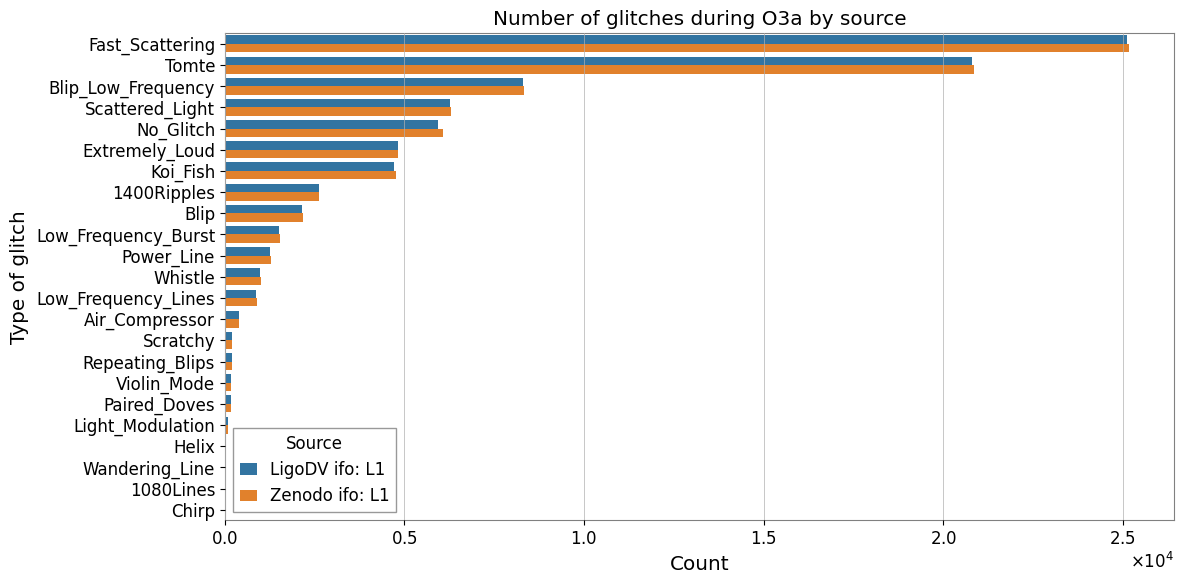

In [ ]:
# Adiciona a origem
df2ligo_L1_O3a['Fonte'] = 'LigoDV ifo: L1'
df2zenodo_L1_O3a['Fonte'] = 'Zenodo ifo: L1'

# Junta os dois DataFrames
df_combined = pd.concat([df2ligo_L1_O3a, df2zenodo_L1_O3a])

# Garante que a ordem seja pela soma total de ocorrências
ordered_labels = (
    df_combined['label']
    .value_counts()
    .loc[lambda x: x.index.isin(df_combined['label'].unique())]
    .index
)

# Gráfico
plt.figure(figsize=(12, 6))
sns.countplot(
    data=df_combined,
    y='label',
    hue='Fonte',
    order=ordered_labels,
    dodge=True  # reforça o uso de barras lado a lado
)

plt.title("Number of glitches during O3a by source")
plt.xlabel("Count")
plt.ylabel("Type of glitch")
plt.legend(title='Source')
plt.tight_layout()
plt.show()

And for O3b run too

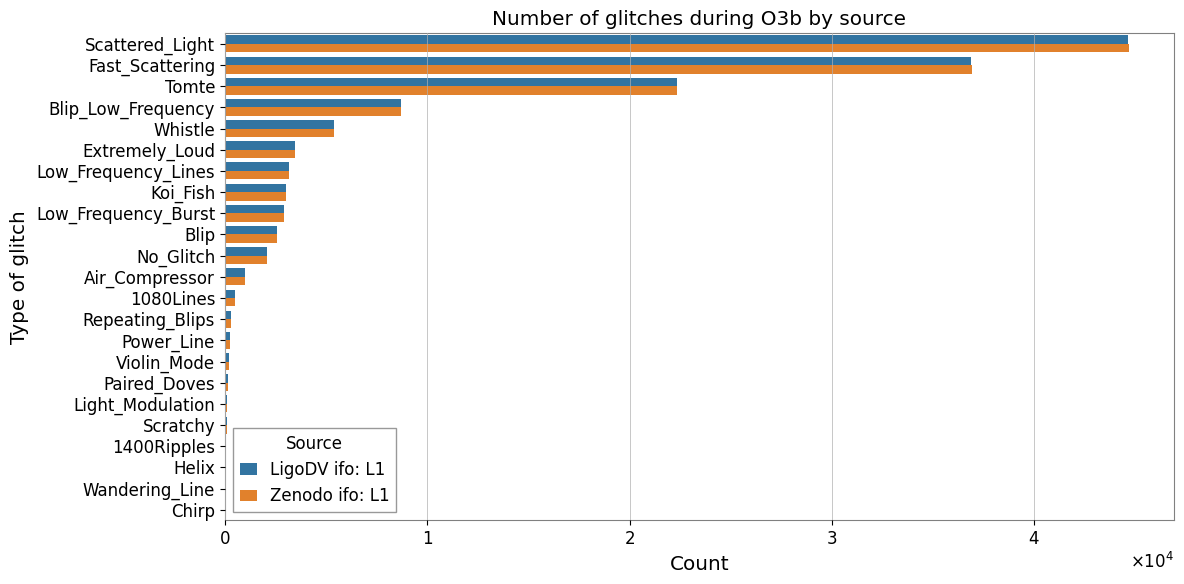

In [ ]:
# Adiciona a origem
df2ligo_L1_O3b['Fonte'] = 'LigoDV ifo: L1'
df2zenodo_L1_O3b['Fonte'] = 'Zenodo ifo: L1'

# Junta os dois DataFrames
df_combined = pd.concat([df2ligo_L1_O3b, df2zenodo_L1_O3b])

# Garante que a ordem seja pela soma total de ocorrências
ordered_labels = (
    df_combined['label']
    .value_counts()
    .loc[lambda x: x.index.isin(df_combined['label'].unique())]
    .index
)

# Gráfico
plt.figure(figsize=(12, 6))
sns.countplot(
    data=df_combined,
    y='label',
    hue='Fonte',
    order=ordered_labels,
    dodge=True  # reforça o uso de barras lado a lado
)

plt.title("Number of glitches during O3b by source")
plt.xlabel("Count")
plt.ylabel("Type of glitch")
plt.legend(title='Source')
plt.tight_layout()
plt.show()

We can see that fast-scattering and scattering-light are the glitches that occurred the most during the O3b run - around November 1st 2019 - March 27th 2020. This agreed with Tabata teses (https://www.gov.br/inpe/pt-br/area-conhecimento/posgraduacao/ast/repositorio-de-arquivos/teses/tese_tabata_aira_ferreira.pdf).

The LIGO website has data from V1 interferometer, let we see

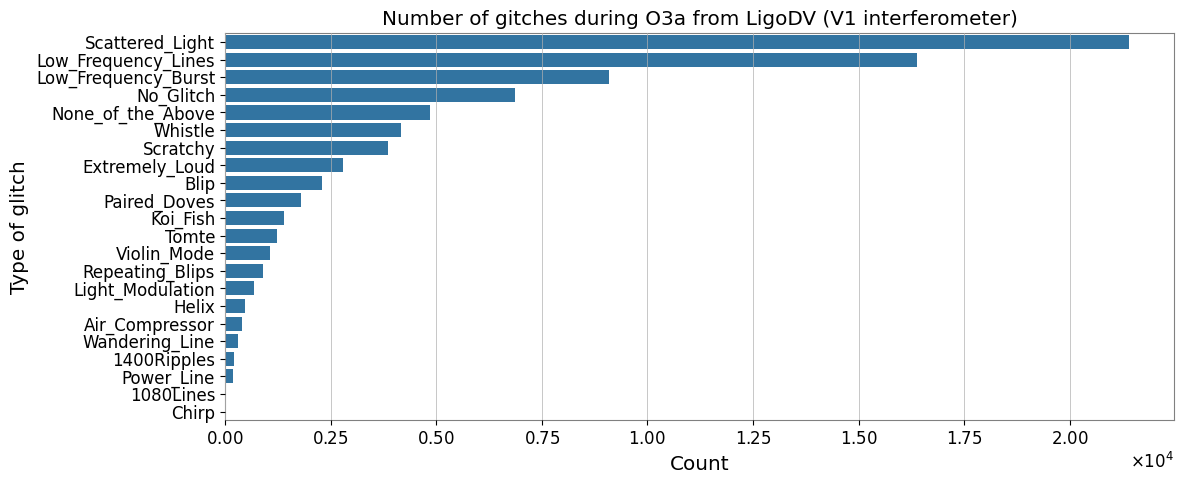

In [ ]:
plt.figure(figsize=(12, 5))

sns.countplot(data=df2ligo_V1_O3a, y='label', order=df2ligo_V1_O3a['label'].value_counts().index)
plt.title("Number of gitches during O3a from LigoDV (V1 interferometer)")
plt.xlabel("Count")
plt.ylabel("Type of glitch")

plt.tight_layout()
plt.show()

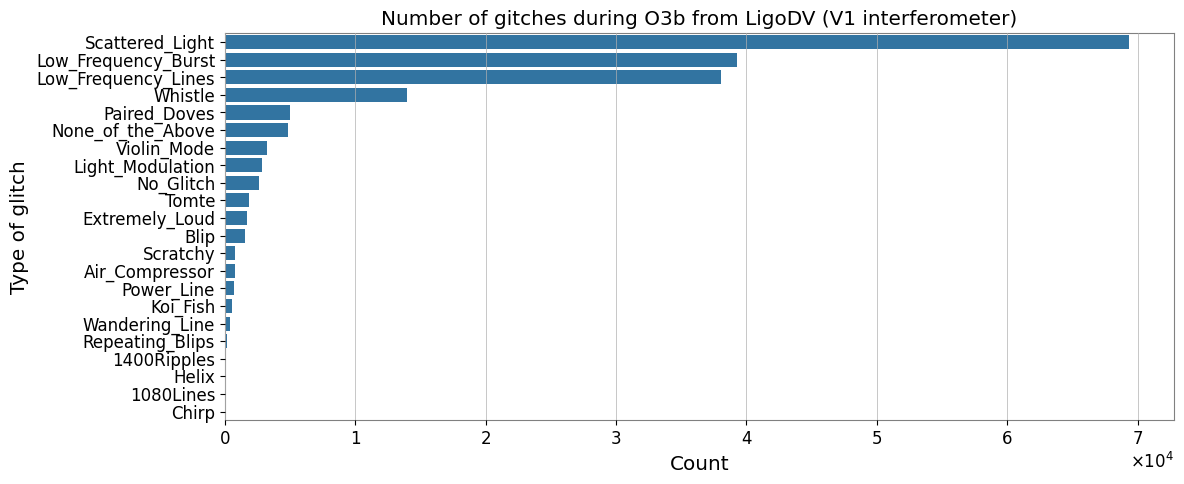

In [ ]:
plt.figure(figsize=(12, 5))

sns.countplot(data=df2ligo_V1_O3b, y='label', order=df2ligo_V1_O3b['label'].value_counts().index)
plt.title("Number of gitches during O3b from LigoDV (V1 interferometer)")
plt.xlabel("Count")
plt.ylabel("Type of glitch")

plt.tight_layout()
plt.show()

# Time-tracking of the incidence of each glitch category throughout O3 (monthly, by season, …);